# Implied Equity Duration — Dechow, Sloan & Soliman (2002)

**Clean-surplus, accounting-based implementation. Annual data. Finite-horizon CFs plus residual level perpetuity.**

## 1. Setup and Paper Goal

### DSS (2002) Logic

Dechow, Sloan & Soliman (2002) construct *implied equity duration* by decomposing the observed market value of equity into:

1. **Finite-horizon discounted cash flows** (horizons $h = 1, \ldots, H$),
2. **A residual terminal value** — inferred as the difference between observed market equity and the discounted finite-horizon CFs.

Cash flows are defined via **clean surplus accounting**:
$$
CF_{t+h} = E_{t+h} - (BE_{t+h} - BE_{t+h-1}) = BE_{t+h-1}(ROE_{t+h} - g_{t+h})
$$
where $E$ = net income, $BE$ = book equity, $ROE$ = return on equity, $g$ = book equity growth.

Future ROE and equity growth are **forecast via mean-reverting AR(1) processes**:
$$
E_t[ROE_{t+h}] = r + \rho_{\text{roe}}^h (ROE_t - r)
$$
$$
E_t[g_{t+h}] = \bar{g} + \rho_g^h (YG_t - \bar{g})
$$
where $r$ is the cost of equity, $\bar{g}$ is long-run growth, and $YG_t$ is the sales growth rate (used as the predictor for future book equity growth).

The **terminal residual** is treated as a **level perpetuity** (no growth) starting at $H+1$:
$$
TV_{\text{residual}} = ME_t - \sum_{h=1}^{H} \frac{E_t[CF_{t+h}]}{(1+r)^h}
$$

**Macaulay-style implied duration:**
$$
D_{it} = \frac{1}{ME_t}\left[
\sum_{h=1}^{H} h \cdot \frac{E_t[CF_{t+h}]}{(1+r)^h}
+ TV_{\text{residual}} \cdot \left(H + \frac{1+r}{r}\right)
\right]
$$
The terminal term $H + (1+r)/r$ is the exact Macaulay duration of a level perpetuity starting at $H+1$, measured from $t=0$.

### What is exact DSS-style vs. what is an approximation

| Component | DSS-exact | Approximation here |
|---|---|---|
| Clean-surplus CF definition | ✓ | — |
| ROE mean-reversion forecast | ✓ | — |
| Sales growth as growth predictor | ✓ | Missing sales → use BEG fallback |
| BE lag path (DSS linear approx.) | ✓ (baseline) | Recursive alternative also shown |
| Level perpetuity terminal | ✓ | — |
| CAPM cost of equity | ✓ (baseline) | Constant-$r$ also shown |
| Annual fiscal-year data | ✓ | Input is quarterly; aggregated to annual |

**⚠ Sales data note:** `euro500_implied.parquet` does not contain a sales/revenue field. Sales is sourced from `euro500_netpayout.parquet` and merged by firm-year. If sales are unavailable for a firm-year, the notebook falls back to using book equity growth ($BEG_t$) instead of sales growth ($YG_t$) as the growth predictor. This is flagged in the output and is a deviation from the DSS paper.

In [9]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
from IPython.display import display

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.max_rows", 80)

from project_paths import DATA_DIR, BASE_DIR
from plot_style import COLORS, set_global_plot_style, style_axes

set_global_plot_style()

GRAPHS_DIR = BASE_DIR / "graphs"
GRAPHS_DIR.mkdir(parents=True, exist_ok=True)

def save_parquet(df: pd.DataFrame, name: str) -> None:
    path = DATA_DIR / f"{name}.parquet"
    df.to_parquet(path, index=False)
    print(f"Saved: {path}  ({len(df):,} rows x {len(df.columns)} cols)")

def load_parquet(name: str) -> pd.DataFrame:
    return pd.read_parquet(DATA_DIR / f"{name}.parquet")

print("Setup complete.")
print(f"DATA_DIR : {DATA_DIR}")
print(f"BASE_DIR : {BASE_DIR}")

Setup complete.
DATA_DIR : /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/intermediate
BASE_DIR : /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data


## 2. Load Data and Inspect Structure

In [10]:
# ── Load primary input ──────────────────────────────────────────────────────
implied_path   = DATA_DIR / "euro500_implied.parquet"
netpayout_path = DATA_DIR / "euro500_netpayout.parquet"

for p in [implied_path, netpayout_path]:
    if not p.exists():
        raise FileNotFoundError(f"Required file not found: {p}")

df_raw = pd.read_parquet(implied_path)
np_raw = pd.read_parquet(netpayout_path)

print("=" * 60)
print("euro500_implied.parquet")
print("=" * 60)
print(f"  Shape   : {df_raw.shape}")
print(f"  Columns : {list(df_raw.columns)}")
df_raw["date"] = pd.to_datetime(df_raw["date"], errors="coerce")
print(f"  Date range: {df_raw['date'].min().date()} → {df_raw['date'].max().date()}")
print(f"  Unique firms: {df_raw['firm_id'].nunique():,}")
print()
print("dtype summary:")
display(df_raw.dtypes.to_frame("dtype"))

print()
print("Numeric coverage (non-null share):")
display(df_raw.select_dtypes(include="number").notna().mean().round(3).to_frame("coverage"))

print()
print("Sample rows:")
display(df_raw.head(3))

euro500_implied.parquet
  Shape   : (56500, 29)
  Columns : ['date', 'formation_date', 'effective_date', 'quarter', 'RIC', 'name', 'firm_id', 'hq_country', 'hq_code', 'trbc_sector', 'trbc_sector_code', 'mcap_eur', 'RIC_current', 'ISIN', 'SEDOL', 'first_trade_date', 'ipo_date', 'FreeFloat', 'FreeFloatPct', 'Volume', 'shares_outstanding', 'PriceClose', 'InstrumentType', 'Currency', 'rank_mcap', 'beta', 'market_risk_free_rate_annual', 'Net_Income', 'Book_Equity']
  Date range: 1997-12-31 → 2025-12-31
  Unique firms: 1,248

dtype summary:


,dtype
date,datetime64[ns]
formation_date,datetime64[ns]
effective_date,datetime64[ns]
quarter,object
RIC,object
name,string[python]
firm_id,string[python]
hq_country,string[python]
hq_code,string[python]
trbc_sector,string[python]



Numeric coverage (non-null share):


,coverage
mcap_eur,1.0000
FreeFloat,0.9750
FreeFloatPct,0.9750
Volume,0.9760
shares_outstanding,0.9930
PriceClose,0.9930
rank_mcap,1.0000
beta,0.9340
market_risk_free_rate_annual,0.9820
Net_Income,0.9580



Sample rows:


,date,formation_date,effective_date,quarter,RIC,name,firm_id,hq_country,hq_code,trbc_sector,trbc_sector_code,mcap_eur,RIC_current,ISIN,SEDOL,first_trade_date,ipo_date,FreeFloat,FreeFloatPct,Volume,shares_outstanding,PriceClose,InstrumentType,Currency,rank_mcap,beta,market_risk_free_rate_annual,Net_Income,Book_Equity
0,1997-12-31,1997-12-31,1998-01-01,1998Q1,DTEGn.DE,Deutsche Telekom AG,FIRM0000557,Germany,DE,Technology,57,46211813784.3400,DTEGn.DE,DE0005557508,5842359,1996-11-18,2000-01-24,501789960,18.2888,0,2699473550.4010,17.1188,Ordinary Shares,EUR,1,NaN,NaN,1690330959.2347,23215719157.5955
1,1997-12-31,1997-12-31,1998-01-01,1998Q1,SIMG.F,Simona AG,FIRM0000907,Germany,DE,Basic Materials,51,69537617.4497,SIM0.F,DE000A3E5CP0,4809946,1996-11-12,1990-05-04,6000000,100.0000,<NA>,<NA>,<NA>,Ordinary Shares,EUR,342,NaN,NaN,<NA>,<NA>
2,1997-12-31,1997-12-31,1998-01-01,1998Q1,NSCP.PA,NSC Groupe SA,FIRM0000347,France,FR,Industrials,52,71544471.1938,ALNSC.PA,FR0000064529,4617611,1991-03-25,1991-03-25,411540,53.3774,10,594804.7743,120.2823,Ordinary Shares,EUR,341,NaN,NaN,<NA>,<NA>


In [11]:
print("=" * 60)
print("euro500_netpayout.parquet")
print("=" * 60)
print(f"  Shape   : {np_raw.shape}")
print(f"  Columns : {list(np_raw.columns)}")
np_raw["date"] = pd.to_datetime(np_raw["date"], errors="coerce")
print(f"  Date range: {np_raw['date'].min().date()} → {np_raw['date'].max().date()}")
print(f"  Unique firms: {np_raw['firm_id'].nunique():,}")
print()
display(np_raw.head(3))

euro500_netpayout.parquet
  Shape   : (16872, 13)
  Columns : ['firm_id', 'date', 'BE', 'assets', 'debt', 'Sales', 'NetIncome', 'GrossProfit', 'Cogs', 'Dividends', 'Buybacks', 'CashSTInvst', 'mcap_eur']
  Date range: 1995-12-30 → 2025-09-30
  Unique firms: 1,125



,firm_id,date,BE,assets,debt,Sales,NetIncome,GrossProfit,Cogs,Dividends,Buybacks,CashSTInvst,mcap_eur
0,FIRM0000001,1998-11-30,92670119.5912,201941375.2729,54100816.5331,296097820.3627,15384772.7052,145027942.1013,151069878.2614,10021320.8714,0.0000,20117801.6494,138569059.7810
1,FIRM0000001,1999-11-30,104237075.8195,264407949.5662,101319133.0535,305313856.5213,15307056.3393,148917850.7334,156396005.7878,<NA>,<NA>,39481959.0660,121992375.0000
2,FIRM0000001,2000-11-30,108772234.8057,265103817.8165,99152278.0610,379503331.0666,14892398.6236,184504276.9566,194999054.1100,11046972.3851,<NA>,21139362.8281,192793450.0000


In [12]:
# ── Column mapping table ─────────────────────────────────────────────────────
# Robustly identify key fields across possible naming conventions.

def _first_match(candidates, cols):
    return next((c for c in candidates if c in cols), None)

all_implied_cols = set(df_raw.columns)
all_np_cols     = set(np_raw.columns)

FIELD_SPECS = [
    # (internal_name, source, candidates, required)
    ("firm_id",   "implied",   ["firm_id", "company_id", "ds_code"],          True),
    ("date",      "implied",   ["date", "effective_date"],                      True),
    ("name",      "implied",   ["name"],                                        False),
    ("isin",      "implied",   ["ISIN", "isin"],                                False),
    ("sector",    "implied",   ["trbc_sector", "sector", "gics_sector"],        False),
    ("mcap_eur",  "implied",   ["mcap_eur", "market_cap", "MarketCap"],         True),
    ("price",     "implied",   ["PriceClose", "price", "Price"],                False),
    ("shares",    "implied",   ["shares_outstanding", "shares"],                False),
    ("beta",      "implied",   ["beta", "Beta"],                                False),
    ("rf",        "implied",   ["market_risk_free_rate_annual", "rf_estr_annual"], False),
    # Accounting — primary source is netpayout
    ("NI_col",    "netpayout", ["NetIncome", "Net_Income", "net_income"],        True),
    ("BE_col",    "netpayout", ["BE", "Book_Equity", "book_equity"],             True),
    ("Sales_col", "netpayout", ["Sales", "sales", "Revenue", "revenue",
                                 "net_sales", "total_revenue"],                  False),
]

resolved = {}
rows = []
for internal, src, candidates, required in FIELD_SPECS:
    pool = all_implied_cols if src == "implied" else all_np_cols
    match = _first_match(candidates, pool)
    resolved[internal] = match
    status = "FOUND" if match else ("MISSING (required!)" if required else "missing (optional)")
    rows.append({"internal": internal, "source": src,
                 "original_column": match or "—", "status": status})

mapping_df = pd.DataFrame(rows)
print("Column mapping (original → internal):")
display(mapping_df.to_string(index=False))

# Raise on required fields
missing_req = [r["internal"] for r in rows if "required!" in r["status"]]
if missing_req:
    raise KeyError(f"Required columns not found: {missing_req}")

# Sales availability flag — prominently reported
SALES_AVAILABLE = resolved["Sales_col"] is not None
if SALES_AVAILABLE:
    print(f"\n✓ Sales column found in netpayout: '{resolved['Sales_col']}'")
    print("  → Growth predictor: YG_t (sales growth). Paper-near DSS implementation.")
else:
    print("\n⚠ WARNING: No sales/revenue column found in euro500_netpayout.parquet.")
    print("  → Falling back to BEG_t (book equity growth) as growth predictor.")
    print("  → This is a deviation from DSS (2002). Results are less paper-near.")

Column mapping (original → internal):


' internal    source              original_column status\n  firm_id   implied                      firm_id  FOUND\n     date   implied                         date  FOUND\n     name   implied                         name  FOUND\n     isin   implied                         ISIN  FOUND\n   sector   implied                  trbc_sector  FOUND\n mcap_eur   implied                     mcap_eur  FOUND\n    price   implied                   PriceClose  FOUND\n   shares   implied           shares_outstanding  FOUND\n     beta   implied                         beta  FOUND\n       rf   implied market_risk_free_rate_annual  FOUND\n   NI_col netpayout                    NetIncome  FOUND\n   BE_col netpayout                           BE  FOUND\nSales_col netpayout                        Sales  FOUND'


✓ Sales column found in netpayout: 'Sales'
  → Growth predictor: YG_t (sales growth). Paper-near DSS implementation.


## 3. Data Preparation

**Aggregation strategy:** `euro500_implied.parquet` is quarterly. We aggregate to annual by taking the latest quarterly observation per firm-calendar-year. This approximates fiscal year-end market data (valid for December fiscal year-end firms, which dominate the European universe).

**Accounting data:** Book equity, net income, and sales are sourced from `euro500_netpayout.parquet`, which contains annual fiscal-year observations. These are merged to the annual implied panel by firm-year.

**ROE and BEG** are constructed from current and lagged book equity and net income.

In [13]:
# ── Step 1: Aggregate implied (quarterly) → annual ───────────────────────────
df = df_raw.copy()
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["firm_id"] = df["firm_id"].astype(str).str.strip()
df["year"] = df["date"].dt.year

# Latest quarterly obs per firm-year (proxy for fiscal year-end market data)
df_annual = (
    df.sort_values(["firm_id", "date"])
    .drop_duplicates(subset=["firm_id", "year"], keep="last")
    .copy()
)

# Keep only relevant columns from implied
keep_implied = ["firm_id", "year", "date"]
for field in ["name", "isin", "sector", "mcap_eur", "price", "shares", "beta", "rf"]:
    col = resolved.get(field)
    if col and col in df_annual.columns:
        keep_implied.append(col)
df_annual = df_annual[keep_implied].copy()

# Standardize internal names
rename_implied = {}
for field, col in resolved.items():
    if col and col in df_annual.columns and field not in ("firm_id", "date"):
        rename_implied[col] = field
df_annual = df_annual.rename(columns=rename_implied)

print(f"Implied annual panel: {len(df_annual):,} rows, "
      f"{df_annual['firm_id'].nunique():,} firms, "
      f"years {df_annual['year'].min()}–{df_annual['year'].max()}")

Implied annual panel: 15,551 rows, 1,248 firms, years 1997–2025


In [14]:
# ── Step 2: Annual accounting from netpayout ────────────────────────────────
np_df = np_raw.copy()
np_df["date"] = pd.to_datetime(np_df["date"], errors="coerce")
np_df["firm_id"] = np_df["firm_id"].astype(str).str.strip()
np_df["year"] = np_df["date"].dt.year

NI_COL    = resolved["NI_col"]
BE_COL    = resolved["BE_col"]
SALES_COL = resolved["Sales_col"]  # may be None

np_keep = ["firm_id", "year", NI_COL, BE_COL]
if SALES_COL:
    np_keep.append(SALES_COL)

np_annual = (
    np_df[np_keep]
    .sort_values(["firm_id", "year"])
    .drop_duplicates(subset=["firm_id", "year"], keep="last")
    .rename(columns={NI_COL: "Net_Income", BE_COL: "Book_Equity",
                     **({SALES_COL: "Sales"} if SALES_COL else {})})
    .copy()
)

for col in ["Net_Income", "Book_Equity"] + (["Sales"] if SALES_COL else []):
    np_annual[col] = pd.to_numeric(np_annual[col], errors="coerce")

print(f"Netpayout annual: {len(np_annual):,} rows, "
      f"{np_annual['firm_id'].nunique():,} firms, "
      f"years {np_annual['year'].min()}–{np_annual['year'].max()}")
print(f"Net_Income coverage : {np_annual['Net_Income'].notna().mean():.1%}")
print(f"Book_Equity coverage: {np_annual['Book_Equity'].notna().mean():.1%}")
if SALES_COL:
    print(f"Sales coverage      : {np_annual['Sales'].notna().mean():.1%}")

Netpayout annual: 16,858 rows, 1,125 firms, years 1995–2025
Net_Income coverage : 98.2%
Book_Equity coverage: 99.3%
Sales coverage      : 98.0%


In [15]:
# ── Step 3: Merge implied + netpayout ────────────────────────────────────────
# Mapping: netpayout fiscal year t → implied calendar year t
# Assumption: most European firms have December fiscal year-ends,
# so fiscal year t ends in December of year t, matching Q4 market data.
panel = df_annual.merge(np_annual, on=["firm_id", "year"], how="left")
panel = panel.sort_values(["firm_id", "year"]).reset_index(drop=True)

print(f"Merged panel: {len(panel):,} rows, {panel['firm_id'].nunique():,} firms")
print(f"Net_Income match rate : {panel['Net_Income'].notna().mean():.1%}")
print(f"Book_Equity match rate: {panel['Book_Equity'].notna().mean():.1%}")

Merged panel: 15,551 rows, 1,248 firms
Net_Income match rate : 87.7%
Book_Equity match rate: 89.0%


In [16]:
# ── Step 4: Construct state variables ────────────────────────────────────────

def _to_num(s):
    return pd.to_numeric(s, errors="coerce")

# Market equity: prefer mcap_eur, fallback price*shares
panel["ME_t"] = _to_num(panel.get("mcap_eur", np.nan))
if "price" in panel.columns and "shares" in panel.columns:
    fallback_me = _to_num(panel["price"]) * _to_num(panel["shares"])
    panel["ME_t"] = panel["ME_t"].where(panel["ME_t"].notna() & (panel["ME_t"] > 0), fallback_me)
    n_fallback_me = ((panel["ME_t"] == fallback_me) & fallback_me.notna()).sum()
    print(f"ME_t: {n_fallback_me:,} rows filled via price×shares fallback")
panel["ME_t"] = panel["ME_t"].astype(float)  # ensure plain float64

# Accounting: ensure numeric
panel["Book_Equity"] = _to_num(panel["Book_Equity"])
panel["Net_Income"]  = _to_num(panel["Net_Income"])
if "Sales" in panel.columns:
    panel["Sales"] = _to_num(panel["Sales"])

# Lagged accounting variables (within firm)
for col in ["Book_Equity", "Net_Income"] + (["Sales"] if "Sales" in panel.columns else []):
    panel[f"{col}_lag1"] = panel.groupby("firm_id")[col].shift(1)

# Core state variables
BE_t   = panel["Book_Equity"]
BE_L1  = panel["Book_Equity_lag1"]
NI_t   = panel["Net_Income"]

# ROE_t = Net_Income_t / Book_Equity_{t-1}
# Force plain float64 to avoid pandas nullable-float TypeError in apply loops
panel["BE_t"]   = BE_t.astype(float)
panel["BE_lag1"] = BE_L1.astype(float)
# Re-bind local vars to float64 columns so np.where conditions work cleanly
BE_t  = panel["BE_t"]
BE_L1 = panel["BE_lag1"]
NI_t  = NI_t.astype(float)
panel["ROE_t"]  = np.where(BE_L1 > 0, NI_t / BE_L1, np.nan)

# BEG_t = (BE_t - BE_{t-1}) / BE_{t-1}
panel["BEG_t"] = np.where(BE_L1 > 0, (BE_t - BE_L1) / BE_L1, np.nan)

# YG_t = (Sales_t - Sales_{t-1}) / Sales_{t-1}  (if available)
if "Sales" in panel.columns:
    Sales_t  = panel["Sales"]
    Sales_L1 = panel["Sales_lag1"]
    panel["YG_t"] = np.where(
        Sales_L1.notna() & (Sales_L1 > 0) & Sales_t.notna(),
        (Sales_t - Sales_L1) / Sales_L1,
        np.nan
    )
else:
    panel["YG_t"] = np.nan

# Discount rate columns (filled after parameter block)
panel["rf"]   = _to_num(panel.get("rf", np.nan))
panel["beta"] = _to_num(panel.get("beta", np.nan))

# Book-to-market and price-to-book
panel["BM_t"]  = np.where(panel["ME_t"] > 0, BE_t / panel["ME_t"], np.nan)
panel["PB_t"]  = np.where(BE_t > 0, panel["ME_t"] / BE_t, np.nan)

print("\nState variables constructed:")
state_cols = ["ME_t", "BE_t", "BE_lag1", "ROE_t", "BEG_t", "YG_t", "rf", "beta", "BM_t"]
display(panel[state_cols].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T.round(4))

ME_t: 5,603 rows filled via price×shares fallback

State variables constructed:


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
ME_t,15551.0000,8582412150.8766,19821389900.4417,4172034.9762,29111227.0345,129052409.2319,713803783.1275,2155902782.2033,7044043220.1474,41180761284.7350,94870728996.0247,368302706239.9990
BE_t,13839.0000,5221065996.2970,11866200809.5441,-9951000000.0000,15125383.1085,75006650.7658,400208500.0000,1290558000.0000,4109384000.0000,25439870000.0000,61008260000.0000,168404000000.0000
BE_lag1,13751.0000,5231953576.9834,11880937812.0862,-9951000000.0000,15422681.6979,76465000.0000,402472000.0000,1296300000.0000,4125100000.0000,25510609000.0000,61005500000.0000,168404000000.0000
ROE_t,12372.0000,0.2295,11.0025,-210.3822,-0.4095,-0.0945,0.0654,0.1303,0.2113,0.4450,0.9638,1194.9021
BEG_t,12571.0000,0.4806,22.0376,-117.3333,-0.4855,-0.1896,-0.0012,0.0690,0.1611,0.5595,1.9464,2046.6006
YG_t,12438.0000,0.7752,31.8585,-13.7842,-0.6226,-0.2134,-0.0119,0.0603,0.1560,0.5427,1.7719,2197.9244
rf,15025.0000,0.0162,0.0175,-0.0059,-0.0057,-0.0056,-0.0007,0.0193,0.0330,0.0419,0.0491,0.0516
beta,14298.0000,0.9121,0.6325,-6.4667,-0.1985,0.0751,0.4977,0.8439,1.2452,1.9415,2.7679,8.6818
BM_t,13839.0000,0.7199,0.7534,-8.2879,0.0372,0.1240,0.3216,0.5491,0.9099,1.8172,3.5028,22.1973


In [17]:
# ── Step 5: Quality screens with sample-loss diagnostics ────────────────────
n0 = len(panel)
screens = [
    ("Positive market equity (ME_t > 0)",  panel["ME_t"] > 0),
    ("Positive lagged book equity (BE_lag1 > 0)", panel["BE_lag1"] > 0),
    ("Finite net income",                  panel["Net_Income"].notna()),
    ("Finite ROE_t",                       panel["ROE_t"].notna()),
    ("Finite BEG_t",                       panel["BEG_t"].notna()),
]

diag_rows = []
running_mask = pd.Series(True, index=panel.index)
diag_rows.append({"screen": "(All observations)", "n": n0, "n_dropped": 0, "pct_remaining": 100.0})

for label, mask in screens:
    n_before = running_mask.sum()
    running_mask = running_mask & mask
    n_after = running_mask.sum()
    diag_rows.append({
        "screen": label,
        "n": n_after,
        "n_dropped": n_before - n_after,
        "pct_remaining": 100.0 * n_after / n0
    })

diag_df = pd.DataFrame(diag_rows)
print("Sample loss after sequential quality screens:")
display(diag_df.to_string(index=False))

panel_clean = panel.loc[running_mask].copy()
print(f"\nClean panel: {len(panel_clean):,} rows, "
      f"{panel_clean['firm_id'].nunique():,} firms, "
      f"years {panel_clean['year'].min()}–{panel_clean['year'].max()}")

Sample loss after sequential quality screens:


'                                   screen     n  n_dropped  pct_remaining\n                       (All observations) 15551          0       100.0000\n        Positive market equity (ME_t > 0) 15551          0       100.0000\nPositive lagged book equity (BE_lag1 > 0) 13672       1879        87.9172\n                        Finite net income 12372       1300        79.5576\n                             Finite ROE_t 12372          0        79.5576\n                             Finite BEG_t 12325         47        79.2554'


Clean panel: 12,325 rows, 911 firms, years 1998–2025


## 4. Parameter Choices

All parameters are defined in one block. Robustness variants in Section 9 override individual entries.

In [18]:
# ============================================================
# PARAMETER BLOCK — modify here, propagates to all sections
# ============================================================

PARAMS = {
    # Forecast horizon (years)
    # DSS (2002) use H=10 in their Table 3 baseline.
    "H": 10,

    # ROE persistence: controls mean-reversion speed toward r.
    # DSS (2002) Table 2 Panel A estimate ≈ 0.57. We use 0.57 as baseline.
    # Interpretation: about half the ROE gap closes each year.
    "rho_roe": 0.57,

    # Growth persistence: controls mean-reversion speed of equity/sales growth.
    # DSS (2002) estimate ≈ 0.24 (faster mean-reversion than ROE).
    # We use 0.32 as a slightly conservative baseline.
    "rho_g": 0.32,

    # Long-run (steady-state) equity growth mean.
    # Estimated from sample median sales growth or set to macro-consistent constant.
    # We use 0.03 (3% nominal), conservative for a diversified Euro-area panel.
    # This will be overridden with a sample estimate in the diagnostic block below.
    "g_bar": 0.03,

    # Equity risk premium (annualized) for CAPM cost of equity
    # Standard academic consensus for Euro area: 5%.
    "ERP": 0.05,

    # Constant cost of equity fallback (used if beta or rf missing,
    # or in robustness variant A).
    "r_constant": 0.08,

    # ROE winsorization bounds (prevent extreme forecasts)
    "ROE_lo": -0.50,
    "ROE_hi":  0.50,

    # Growth winsorization bounds
    "BEG_lo": -0.50,
    "BEG_hi":  0.50,

    # Duration output winsorization (flag extreme values)
    "D_max": 100.0,
}

# ── Estimate g_bar from sample median sales growth (if available) ────────────
if "YG_t" in panel_clean.columns and panel_clean["YG_t"].notna().any():
    g_bar_empirical = float(panel_clean["YG_t"].median())
    print(f"Sample median sales growth (YG_t): {g_bar_empirical:.4f}")
    print(f"Using g_bar = {PARAMS['g_bar']:.3f} (fixed) vs empirical {g_bar_empirical:.4f}")
    print("Rationale: fixed 3% is more conservative and less sensitive to sample period.")
    PARAMS["g_bar_empirical"] = g_bar_empirical
elif panel_clean["BEG_t"].notna().any():
    g_bar_empirical = float(panel_clean["BEG_t"].median())
    print(f"Sample median BEG_t (fallback g_bar estimate): {g_bar_empirical:.4f}")
    PARAMS["g_bar_empirical"] = g_bar_empirical
else:
    PARAMS["g_bar_empirical"] = PARAMS["g_bar"]

print("\nBaseline parameters:")
for k, v in PARAMS.items():
    print(f"  {k:<20} = {v}")

Sample median sales growth (YG_t): 0.0604
Using g_bar = 0.030 (fixed) vs empirical 0.0604
Rationale: fixed 3% is more conservative and less sensitive to sample period.

Baseline parameters:
  H                    = 10
  rho_roe              = 0.57
  rho_g                = 0.32
  g_bar                = 0.03
  ERP                  = 0.05
  r_constant           = 0.08
  ROE_lo               = -0.5
  ROE_hi               = 0.5
  BEG_lo               = -0.5
  BEG_hi               = 0.5
  D_max                = 100.0
  g_bar_empirical      = 0.060419747321451736


In [19]:
# ── Construct cost of equity r_it ────────────────────────────────────────────
# Baseline: CAPM r_it = rf_t + beta_it * ERP
# Fallback: r_constant if beta or rf is missing.

ERP = PARAMS["ERP"]
r_const = PARAMS["r_constant"]

panel_clean = panel_clean.copy()
panel_clean["r_capm"] = panel_clean["rf"] + panel_clean["beta"] * ERP

# Flag which observations use the constant-r fallback
panel_clean["flag_r_fallback"] = panel_clean["r_capm"].isna()

# Baseline cost of equity
panel_clean["r_it"] = panel_clean["r_capm"].fillna(r_const)

# Guard: r must be positive for perpetuity formula to be valid
panel_clean["r_it"] = panel_clean["r_it"].clip(lower=0.01)

n_fallback_r = panel_clean["flag_r_fallback"].sum()
n_total_r    = len(panel_clean)
print(f"Cost of equity (r_it):")
print(f"  CAPM rate  : {(~panel_clean['flag_r_fallback']).sum():,} obs ({(~panel_clean['flag_r_fallback']).mean():.1%})")
print(f"  Fallback r : {n_fallback_r:,} obs ({n_fallback_r/n_total_r:.1%}) — using r_constant={r_const:.0%}")
print()
display(panel_clean["r_it"].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).round(4))

# Winsorize ROE and BEG for forecasting robustness
panel_clean["ROE_t_w"] = panel_clean["ROE_t"].clip(
    PARAMS["ROE_lo"], PARAMS["ROE_hi"]
)
panel_clean["BEG_t_w"] = panel_clean["BEG_t"].clip(
    PARAMS["BEG_lo"], PARAMS["BEG_hi"]
)
if "YG_t" in panel_clean.columns:
    panel_clean["YG_t_w"] = panel_clean["YG_t"].clip(
        PARAMS["BEG_lo"], PARAMS["BEG_hi"]
    ).astype(float)
else:
    panel_clean["YG_t_w"] = np.nan

print("\nWinsorized state variables (ROE_t_w, BEG_t_w, YG_t_w):")
display(panel_clean[["ROE_t_w", "BEG_t_w", "YG_t_w"]].describe(
    percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).round(4))

Cost of equity (r_it):
  CAPM rate  : 12,214 obs (99.1%)
  Fallback r : 111 obs (0.9%) — using r_constant=8%



count   12325.0000
mean        0.0614
std         0.0342
min         0.0100
1%          0.0100
5%          0.0126
25%         0.0370
50%         0.0581
75%         0.0804
95%         0.1184
99%         0.1589
max         0.4832
Name: r_it, dtype: float64


Winsorized state variables (ROE_t_w, BEG_t_w, YG_t_w):


,ROE_t_w,BEG_t_w,YG_t_w
count,12325.0000,12325.0000,12249.0000
mean,0.1390,0.0861,0.0772
std,0.1563,0.1810,0.1873
min,-0.5000,-0.5000,-0.5000
1%,-0.4092,-0.4847,-0.5000
5%,-0.0943,-0.1889,-0.2121
50%,0.1303,0.0691,0.0604
95%,0.4438,0.5000,0.5000
99%,0.5000,0.5000,0.5000
max,0.5000,0.5000,0.5000


## 5. Forecasting Logic

Two implementations of the BE lag path:

**Version A — DSS linear approximation (baseline):**
$$E_t[BE_{t+h-1}] = \begin{cases} BE_t & h = 1 \\ BE_t\bigl(1 + \bar{g} + \rho_g^{h-1}(YG_t - \bar{g})\bigr) & h \geq 2 \end{cases}$$
This linearizes the BE path — equivalent to applying the single-period forecasted growth rate at horizon $h-1$ rather than compounding.

**Version B — Recursive compounding (robustness):**
$$E_t[BE_{t+h}] = E_t[BE_{t+h-1}] \cdot (1 + E_t[g_{t+h}])$$

Both produce the same clean-surplus expected CFs:
$$E_t[CF_{t+h}] = E_t[BE_{t+h-1}] \cdot (E_t[ROE_{t+h}] - E_t[g_{t+h}])$$

In [20]:
# ── Core forecasting functions ────────────────────────────────────────────────

def forecast_roe(ROE_t, r, rho_roe, H):
    """E_t[ROE_{t+h}] = r + rho_roe^h * (ROE_t - r), for h=1..H."""
    h_arr = np.arange(1, H + 1, dtype=float)
    return r + rho_roe ** h_arr * (ROE_t - r)


def forecast_growth(growth_t, g_bar, rho_g, H):
    """E_t[g_{t+h}] = g_bar + rho_g^h * (growth_t - g_bar), for h=1..H."""
    h_arr = np.arange(1, H + 1, dtype=float)
    return g_bar + rho_g ** h_arr * (growth_t - g_bar)


def be_lag_dss(BE_t, growth_t, g_bar, rho_g, H):
    """
    Version A: DSS linear approximation for E_t[BE_{t+h-1}], h=1..H.
    h=1 → BE_t (exact). h>=2 → BE_t * (1 + g_bar + rho_g^(h-1) * (growth_t - g_bar)).
    """
    path = np.empty(H, dtype=float)
    path[0] = BE_t  # h=1: known exactly
    for h in range(2, H + 1):
        path[h - 1] = BE_t * (1.0 + g_bar + rho_g ** (h - 1) * (growth_t - g_bar))
    return path


def be_lag_recursive(BE_t, growth_t, g_bar, rho_g, H):
    """
    Version B: Recursive BE path.
    be_lag[h-1] = E_t[BE_{t+h-1}], compounded from BE_t.
    """
    path = np.empty(H, dtype=float)
    be = BE_t
    for h in range(1, H + 1):
        path[h - 1] = be  # lagged BE for period t+h CF
        g_h = g_bar + rho_g ** h * (growth_t - g_bar)
        be = be * (1.0 + g_h)
    return path


def forecast_cashflows(ROE_t, growth_t, BE_t, r, params, version="dss"):
    """
    Full forecast of expected clean-surplus CFs for h=1..H.

    Returns
    -------
    roe_hat, beg_hat, be_lag_path, cf_hat : np.ndarray of shape (H,)
    """
    H     = params["H"]
    rho_roe = params["rho_roe"]
    rho_g   = params["rho_g"]
    g_bar   = params["g_bar"]

    roe_hat = forecast_roe(ROE_t, r, rho_roe, H)
    beg_hat = forecast_growth(growth_t, g_bar, rho_g, H)

    if version == "dss":
        be_lag = be_lag_dss(BE_t, growth_t, g_bar, rho_g, H)
    elif version == "recursive":
        be_lag = be_lag_recursive(BE_t, growth_t, g_bar, rho_g, H)
    else:
        raise ValueError(f"version must be 'dss' or 'recursive', got '{version}'")

    cf_hat = be_lag * (roe_hat - beg_hat)
    return roe_hat, beg_hat, be_lag, cf_hat


print("Forecasting functions defined: forecast_roe, forecast_growth,")
print("  be_lag_dss, be_lag_recursive, forecast_cashflows.")

Forecasting functions defined: forecast_roe, forecast_growth,
  be_lag_dss, be_lag_recursive, forecast_cashflows.


Demo firm-year: GEA Group AG, 2013
  ROE_t=0.1303, growth_t=0.0429, r_it=0.0585
  BE_t=2,313,035,000



,horizon,E[ROE],E[BEG],E[BE_lag] DSS,E[BE_lag] Recursive,E[CF/BE0] DSS,E[CF/BE0] Recursive
0,1,0.0994,0.0341,1.0000,1.0000,0.0653,0.0653
1,2,0.0818,0.0313,1.0341,1.0341,0.0522,0.0522
2,3,0.0718,0.0304,1.0313,1.0665,0.0427,0.0441
3,4,0.0661,0.0301,1.0304,1.0990,0.0371,0.0395
4,5,0.0628,0.0300,1.0301,1.1321,0.0338,0.0371
5,6,0.0610,0.0300,1.0300,1.1661,0.0319,0.0361
6,7,0.0599,0.0300,1.0300,1.2011,0.0308,0.0359
7,8,0.0593,0.0300,1.0300,1.2371,0.0302,0.0363
8,9,0.0590,0.0300,1.0300,1.2742,0.0298,0.0369
9,10,0.0588,0.0300,1.0300,1.3125,0.0296,0.0378


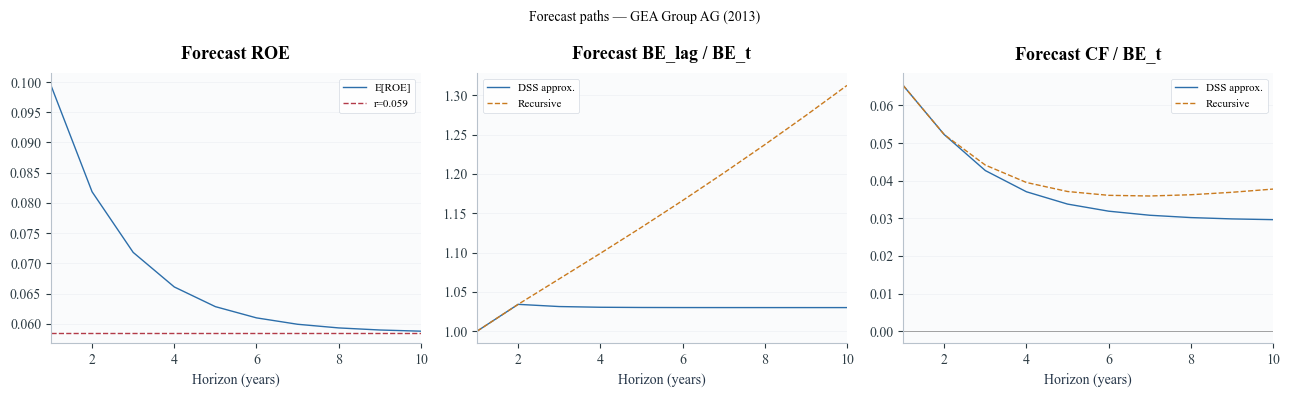

In [21]:
# ── Diagnostic: show example forecast paths for a median-like firm ───────────

# Pick the firm-year closest to panel medians for illustration
def _median_obs(df):
    from numpy import abs as nabs
    score = (
        nabs(df["ROE_t_w"] - df["ROE_t_w"].median()).fillna(999)
        + nabs(df["BEG_t_w"] - df["BEG_t_w"].median()).fillna(999)
        + nabs(df["r_it"] - df["r_it"].median()).fillna(999)
    )
    return df.loc[score.idxmin()]

demo = _median_obs(panel_clean)
growth_demo = demo["YG_t_w"] if pd.notna(demo.get("YG_t_w", np.nan)) else demo["BEG_t_w"]

r_demo   = float(demo["r_it"])
ROE_demo = float(demo["ROE_t_w"])
BEG_demo = float(demo["BEG_t_w"])
BE_demo  = float(demo["BE_t"])
growth_demo = float(growth_demo)

H_demo = PARAMS["H"]

roe_hat_A, beg_hat_A, be_lag_A, cf_A = forecast_cashflows(
    ROE_demo, growth_demo, BE_demo, r_demo, PARAMS, version="dss")
roe_hat_B, beg_hat_B, be_lag_B, cf_B = forecast_cashflows(
    ROE_demo, growth_demo, BE_demo, r_demo, PARAMS, version="recursive")

demo_path = pd.DataFrame({
    "horizon":    np.arange(1, H_demo + 1),
    "E[ROE]": roe_hat_A,
    "E[BEG]": beg_hat_A,
    "E[BE_lag] DSS":       be_lag_A / BE_demo,  # scaled to 1
    "E[BE_lag] Recursive": be_lag_B / BE_demo,
    "E[CF/BE0] DSS":       cf_A / BE_demo,
    "E[CF/BE0] Recursive": cf_B / BE_demo,
})

firm_label = demo.get("name", demo["firm_id"])
print(f"Demo firm-year: {firm_label}, {int(demo['year'])}")
print(f"  ROE_t={ROE_demo:.4f}, growth_t={growth_demo:.4f}, r_it={r_demo:.4f}")
print(f"  BE_t={BE_demo:,.0f}")
print()
display(demo_path.round(4))

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
h = demo_path["horizon"]
axes[0].plot(h, demo_path["E[ROE]"], color=COLORS["blue"], label="E[ROE]")
axes[0].axhline(r_demo, color=COLORS["accent"], ls="--", lw=1, label=f"r={r_demo:.3f}")
axes[0].set_title("Forecast ROE"); axes[0].set_xlabel("Horizon (years)")
axes[0].legend(fontsize=8); style_axes(axes[0])

axes[1].plot(h, demo_path["E[BE_lag] DSS"],       color=COLORS["blue"],   label="DSS approx.")
axes[1].plot(h, demo_path["E[BE_lag] Recursive"],  color=COLORS["orange"], label="Recursive", ls="--")
axes[1].set_title("Forecast BE_lag / BE_t"); axes[1].set_xlabel("Horizon (years)")
axes[1].legend(fontsize=8); style_axes(axes[1])

axes[2].plot(h, demo_path["E[CF/BE0] DSS"],       color=COLORS["blue"],   label="DSS approx.")
axes[2].plot(h, demo_path["E[CF/BE0] Recursive"],  color=COLORS["orange"], label="Recursive", ls="--")
axes[2].axhline(0, color="grey", lw=0.5)
axes[2].set_title("Forecast CF / BE_t"); axes[2].set_xlabel("Horizon (years)")
axes[2].legend(fontsize=8); style_axes(axes[2])

plt.suptitle(f"Forecast paths — {firm_label} ({int(demo['year'])})", fontsize=10)
plt.tight_layout()
plt.show()

## 6. Present Value and Terminal Residual

For each firm-year:
$$PV_{\text{forecast}} = \sum_{h=1}^{H} \frac{E_t[CF_{t+h}]}{(1+r)^h}$$
$$TV_{\text{residual}} = ME_t - PV_{\text{forecast}}$$

The terminal residual $TV_{\text{residual}}$ is treated as the **present value (at $t=0$) of a level perpetuity starting at $H+1$**. Observations with $TV_{\text{residual}} \leq 0$ imply that finite-horizon CFs alone exceed observed market value — economically, this flags firms where the DSS model is misspecified or accounting data is unreliable. We report rather than silently drop these.

In [22]:
# ── Core duration computation function ───────────────────────────────────────

def _sf(v, default=np.nan):
    """Safe float — converts pd.NA, None, or any missing to default."""
    try:
        return float(v)
    except (TypeError, ValueError):
        return default


def compute_dss_duration(row, params, version="dss", use_sales_growth=True):
    """
    Compute DSS (2002) implied equity duration for a single firm-year.

    Parameters
    ----------
    version           : 'dss' (DSS linear approx) or 'recursive'
    use_sales_growth  : if True, use YG_t_w; else fall back to BEG_t_w

    Returns a pd.Series with duration metrics and diagnostic flags.
    """
    null_result = pd.Series({
        "pv_forecast":      np.nan,
        "pv_terminal":      np.nan,
        "tv_share":         np.nan,
        "implied_duration": np.nan,
        "modified_duration": np.nan,
        "dv01":             np.nan,
        "flag_neg_terminal": False,
        "flag_fallback_growth": False,
    })

    # Extract and validate inputs
    ME  = _sf(row.get("ME_t",   np.nan))
    BE  = _sf(row.get("BE_t",   np.nan))
    ROE = _sf(row.get("ROE_t_w", np.nan))
    BEG = _sf(row.get("BEG_t_w", np.nan))
    r   = _sf(row.get("r_it",   np.nan))
    YG  = _sf(row.get("YG_t_w", np.nan))

    if not all(np.isfinite(x) for x in [ME, BE, ROE, BEG, r]):
        return null_result
    if ME <= 0 or BE <= 0 or r <= 0:
        return null_result

    # Growth predictor
    flag_fallback = False
    if use_sales_growth and np.isfinite(YG):
        growth_pred = YG
    else:
        growth_pred = BEG
        flag_fallback = True

    # Forecast CFs
    _, beg_hat, be_lag, cf_hat = forecast_cashflows(
        ROE, growth_pred, BE, r, params, version=version
    )

    H     = params["H"]
    h_arr = np.arange(1, H + 1, dtype=float)
    disc  = (1.0 + r) ** (-h_arr)
    pv_cfs = cf_hat * disc

    PV_forecast  = float(np.sum(pv_cfs))
    PV_terminal  = ME - PV_forecast          # at t=0
    flag_neg_tv  = PV_terminal <= 0.0
    tv_share     = PV_terminal / ME

    # ── Duration ─────────────────────────────────────────────────────────────
    # Finite contribution
    finite_num = float(np.sum(h_arr * pv_cfs))

    # Terminal contribution:
    # PV_terminal is the PV at t=0 of the level perpetuity.
    # Duration of a level perpetuity starting at H+1 (from t=0) = H + (1+r)/r.
    D_perp = H + (1.0 + r) / r
    terminal_contrib = PV_terminal * D_perp

    D_it  = (finite_num + terminal_contrib) / ME
    D_mod = D_it / (1.0 + r)
    DV01  = D_mod * ME * 1e-4

    return pd.Series({
        "pv_forecast":       PV_forecast,
        "pv_terminal":       PV_terminal,
        "tv_share":          tv_share,
        "implied_duration":  D_it,
        "modified_duration": D_mod,
        "dv01":              DV01,
        "flag_neg_terminal": flag_neg_tv,
        "flag_fallback_growth": flag_fallback,
    })


print("compute_dss_duration() defined.")

compute_dss_duration() defined.


In [23]:
# ── Apply baseline duration computation ──────────────────────────────────────
print("Computing baseline DSS duration (version=dss, CAPM r)...")

dur_results = panel_clean.apply(
    compute_dss_duration,
    axis=1,
    params=PARAMS,
    version="dss",
    use_sales_growth=True,
)

for col in dur_results.columns:
    panel_clean[col] = dur_results[col].values

print("Done.")
print(f"Valid implied_duration: {panel_clean['implied_duration'].notna().sum():,} "
      f"/ {len(panel_clean):,} ({panel_clean['implied_duration'].notna().mean():.1%})")

# ── Terminal residual diagnostics ────────────────────────────────────────────
n_neg_tv = int(panel_clean["flag_neg_terminal"].sum())
n_valid  = panel_clean["implied_duration"].notna().sum()
print(f"\nNegative terminal residual (TV_residual <= 0): {n_neg_tv:,} obs "
      f"({n_neg_tv/len(panel_clean):.1%} of clean panel)")
print(f"Fallback growth predictor used: {panel_clean['flag_fallback_growth'].sum():,} obs")

if n_neg_tv > 0:
    neg_tv = panel_clean[panel_clean["flag_neg_terminal"]]
    print(f"\nNegative TV firms: {neg_tv['firm_id'].nunique():,} unique")
    print("tv_share distribution for negative-TV obs:")
    display(neg_tv["tv_share"].describe().round(4))
    print("\nPossible causes: very high forecasted CFs (high ROE, positive growth),")
    print("or very low/depressed market equity relative to accounting fundamentals.")

# Define two samples
mask_pos_tv = panel_clean["flag_neg_terminal"] == False
panel_baseline = panel_clean[mask_pos_tv & panel_clean["implied_duration"].notna()].copy()
panel_diag     = panel_clean[panel_clean["implied_duration"].notna()].copy()  # includes neg TV

print(f"\nBaseline sample (positive TV, finite duration): {len(panel_baseline):,} obs")
print(f"Diagnostic sample (all finite duration)       : {len(panel_diag):,} obs")

Computing baseline DSS duration (version=dss, CAPM r)...
Done.
Valid implied_duration: 12,300 / 12,325 (99.8%)

Negative terminal residual (TV_residual <= 0): 187 obs (1.5% of clean panel)
Fallback growth predictor used: 76 obs

Negative TV firms: 85 unique
tv_share distribution for negative-TV obs:


count   187.0000
mean     -0.5534
std       0.6668
min      -4.0413
25%      -0.7099
50%      -0.3129
75%      -0.1495
max      -0.0007
Name: tv_share, dtype: float64


Possible causes: very high forecasted CFs (high ROE, positive growth),
or very low/depressed market equity relative to accounting fundamentals.

Baseline sample (positive TV, finite duration): 12,113 obs
Diagnostic sample (all finite duration)       : 12,300 obs


## 7. Implied Equity Duration

In [24]:
# ── Duration summary ─────────────────────────────────────────────────────────
print("Implied equity duration — baseline sample (positive TV):")
display(
    panel_baseline[["implied_duration", "modified_duration", "tv_share", "pv_forecast", "pv_terminal"]]
    .describe(percentiles=[0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99])
    .round(3)
)

print("\nImplied equity duration — full diagnostic sample:")
display(
    panel_diag["implied_duration"]
    .describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
    .round(3)
)

# Fraction above D_max
D_max = PARAMS["D_max"]
n_extreme = (panel_baseline["implied_duration"] > D_max).sum()
print(f"\nObs with duration > {D_max:.0f}: {n_extreme:,} ({n_extreme/len(panel_baseline):.2%})")
print("These are retained but flagged via 'flag_duration_extreme'.")
panel_baseline["flag_duration_extreme"] = panel_baseline["implied_duration"] > D_max
panel_diag["flag_duration_extreme"]     = panel_diag["implied_duration"] > D_max

Implied equity duration — baseline sample (positive TV):


,implied_duration,modified_duration,tv_share,pv_forecast,pv_terminal
count,12113.0000,12113.0000,12113.0000,12113.0000,12113.0000
mean,32.3360,31.0020,0.8340,1552314568.2580,7828366767.8400
std,23.4620,23.5160,0.1880,4133447624.9980,18138298830.4870
min,3.5010,2.7170,0.0060,-10003389772.1400,2757026.5620
1%,7.9280,7.1530,0.2050,-851449987.5580,71855105.0830
5%,12.6880,11.4520,0.4670,-102716310.3260,165705472.8810
10%,15.1270,13.6420,0.5940,-6845095.4010,297673224.8630
25%,18.9690,17.5170,0.7550,60572258.0000,752123246.6250
50%,24.6460,23.2650,0.8720,278679091.8420,2091326329.0490
75%,35.6610,34.3500,0.9470,1086605761.7090,6553476529.3030



Implied equity duration — full diagnostic sample:


count   12300.0000
mean       31.7670
std        23.7790
min       -69.3230
1%          0.9530
5%         11.5900
25%        18.7070
50%        24.4490
75%        35.3300
95%        91.9300
99%       119.7970
max       191.7800
Name: implied_duration, dtype: float64


Obs with duration > 100: 544 (4.49%)
These are retained but flagged via 'flag_duration_extreme'.


## 8. Diagnostics and Validation

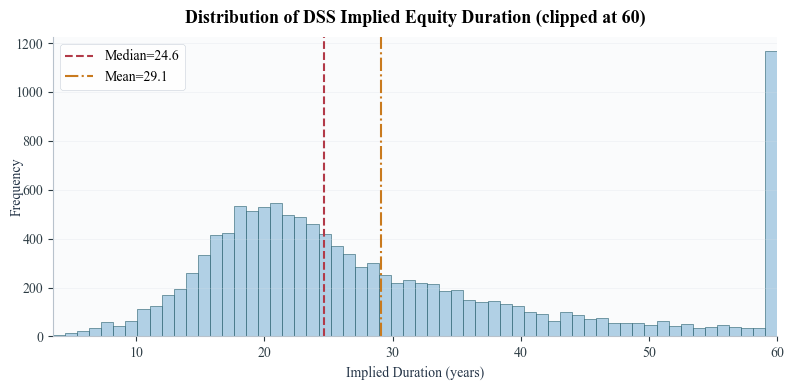

In [25]:
# ── Histogram of duration ────────────────────────────────────────────────────
D_plot = panel_baseline["implied_duration"].clip(upper=60)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(D_plot, bins=60, color=COLORS["blue_light"], edgecolor=COLORS["primary"], alpha=0.9)
ax.axvline(D_plot.median(), color=COLORS["accent"], lw=1.5, ls="--",
           label=f"Median={D_plot.median():.1f}")
ax.axvline(D_plot.mean(), color=COLORS["orange"], lw=1.5, ls="-.",
           label=f"Mean={D_plot.mean():.1f}")
ax.set_title("Distribution of DSS Implied Equity Duration (clipped at 60)")
ax.set_xlabel("Implied Duration (years)")
ax.set_ylabel("Frequency")
ax.legend()
style_axes(ax)
plt.tight_layout()
plt.savefig(GRAPHS_DIR / "implied_duration_histogram.png", dpi=200, bbox_inches="tight")
plt.show()

By-year duration statistics:


' year    mean  median   n\n 1998 21.9261 22.2536 274\n 1999 27.5975 24.3132 354\n 2000 21.4505 19.7243 387\n 2001 24.6006 22.0846 385\n 2002 23.3546 22.3346 440\n 2003 29.1635 26.1559 431\n 2004 29.0992 26.6262 447\n 2005 27.8938 24.4166 450\n 2006 21.9396 20.4715 447\n 2007 19.1462 18.2561 460\n 2008 17.0738 16.8447 459\n 2009 32.5820 26.1148 472\n 2010 30.2034 24.8959 473\n 2011 29.1926 24.9358 457\n 2012 43.4718 32.9717 465\n 2013 43.2251 31.9733 475\n 2014 46.1848 32.6428 460\n 2015 42.9337 33.0893 478\n 2016 41.4349 33.7930 472\n 2017 41.4611 35.1776 480\n 2018 44.9858 33.5224 470\n 2019 45.3529 31.6015 482\n 2020 42.9917 30.3913 480\n 2021 42.3461 30.9001 478\n 2022 31.6582 25.4952 472\n 2023 19.2481 18.7072 467\n 2024 20.0801 19.1157 462\n 2025 33.7488 21.3283  36'

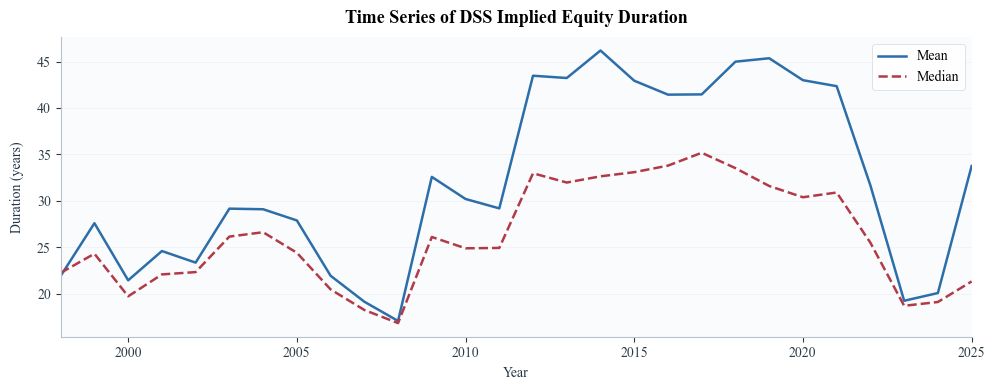

In [26]:
# ── By-year mean and median duration ────────────────────────────────────────
by_year = (
    panel_baseline.groupby("year")["implied_duration"]
    .agg(mean="mean", median="median", n="count")
    .reset_index()
)
print("By-year duration statistics:")
display(by_year.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(by_year["year"], by_year["mean"],   color=COLORS["blue"],   lw=1.8, label="Mean")
ax.plot(by_year["year"], by_year["median"], color=COLORS["accent"], lw=1.8, ls="--", label="Median")
ax.set_title("Time Series of DSS Implied Equity Duration")
ax.set_xlabel("Year")
ax.set_ylabel("Duration (years)")
ax.legend()
style_axes(ax)
plt.tight_layout()
plt.savefig(GRAPHS_DIR / "implied_duration_timeseries.png", dpi=200, bbox_inches="tight")
plt.show()

By-sector duration:


'                                    sector    mean  median    n\n                               Real Estate 44.8601 34.0108  695\n                                Healthcare 42.9961 32.8173  898\n                    Consumer Non-Cyclicals 41.7578 32.2259  862\n                                 Utilities 41.1787 30.0646  650\n                                Technology 32.5156 25.0513 1302\n                                    Energy 31.6683 25.5570  513\n                               Industrials 28.6055 23.5296 2226\n                           Basic Materials 28.2789 23.2679 1300\n                        Consumer Cyclicals 27.5100 22.7399 1922\n                                Financials 27.0795 20.6040 1743\nInstitutions, Associations & Organizations 22.8310 22.8310    2'

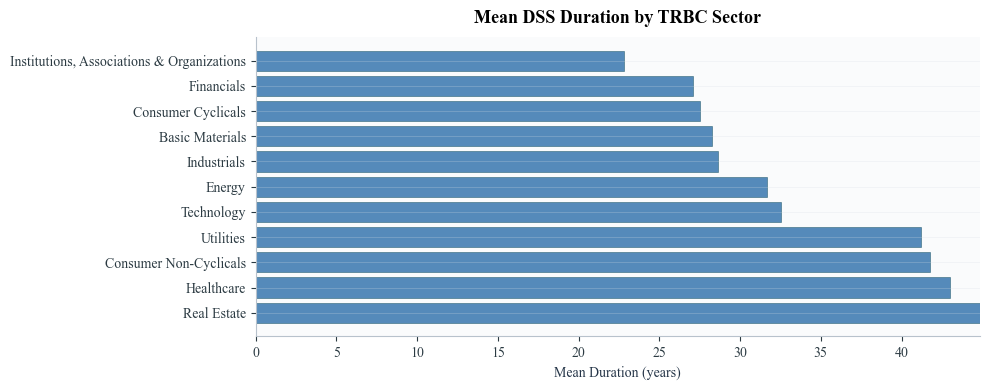

In [27]:
# ── By-sector mean duration ──────────────────────────────────────────────────
if "sector" in panel_baseline.columns and panel_baseline["sector"].notna().any():
    by_sector = (
        panel_baseline.groupby("sector")["implied_duration"]
        .agg(mean="mean", median="median", n="count")
        .sort_values("mean", ascending=False)
        .reset_index()
    )
    print("By-sector duration:")
    display(by_sector.to_string(index=False))

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.barh(by_sector["sector"], by_sector["mean"],
            color=COLORS["blue"], alpha=0.8, edgecolor=COLORS["primary"])
    ax.set_title("Mean DSS Duration by TRBC Sector")
    ax.set_xlabel("Mean Duration (years)")
    style_axes(ax)
    plt.tight_layout()
    plt.savefig(GRAPHS_DIR / "implied_duration_by_sector.png", dpi=200, bbox_inches="tight")
    plt.show()
else:
    print("No sector column available — skipping sector breakdown.")

In [28]:
# ── Correlations ─────────────────────────────────────────────────────────────
corr_vars = {
    "BM_t": "Book-to-market",
    "ME_t": "Market cap",
    "beta": "CAPM beta",
    "ROE_t": "ROE",
    "BEG_t": "Book equity growth",
    "YG_t":  "Sales growth",
    "tv_share": "TV share",
    "r_it": "Cost of equity (r)",
}
avail_corr = [k for k in corr_vars if k in panel_baseline.columns and
              panel_baseline[k].notna().any()]

corr_df = (
    panel_baseline[["implied_duration"] + avail_corr]
    .corr()
    .loc[["implied_duration"], avail_corr]
    .rename(columns=corr_vars)
    .T
    .rename(columns={"implied_duration": "Corr. with implied_duration"})
    .round(3)
)
print("Correlations with implied equity duration:")
display(corr_df)

Correlations with implied equity duration:


,Corr. with implied_duration
Book-to-market,-0.1410
Market cap,-0.0430
CAPM beta,-0.5950
ROE,-0.0050
Book equity growth,0.0000
Sales growth,0.0040
TV share,0.5930
Cost of equity (r),-0.6880


Duration decile means (decile 1=shortest, 10=longest):


,ROE,Book-to-market,Market cap (EUR),CAPM beta,TV share
dur_decile,,,,,
1,0.1732,1.2658,8407463601.6217,1.6461,0.4567
2,0.1697,0.8021,9103318304.2212,1.4461,0.6992
3,1.1563,0.6620,11722194108.4130,1.2044,0.7757
4,0.2203,0.6100,10278077708.5604,1.0549,0.8189
5,-0.0309,0.5912,8571718180.7671,0.9429,0.8514
6,0.1639,0.5928,9709685815.9480,0.8338,0.8773
7,0.1409,0.5851,9889512134.9208,0.7024,0.9052
8,0.0801,0.6011,11404569674.2748,0.5979,0.9394
9,0.1892,0.5881,8072287828.1732,0.4632,0.9805


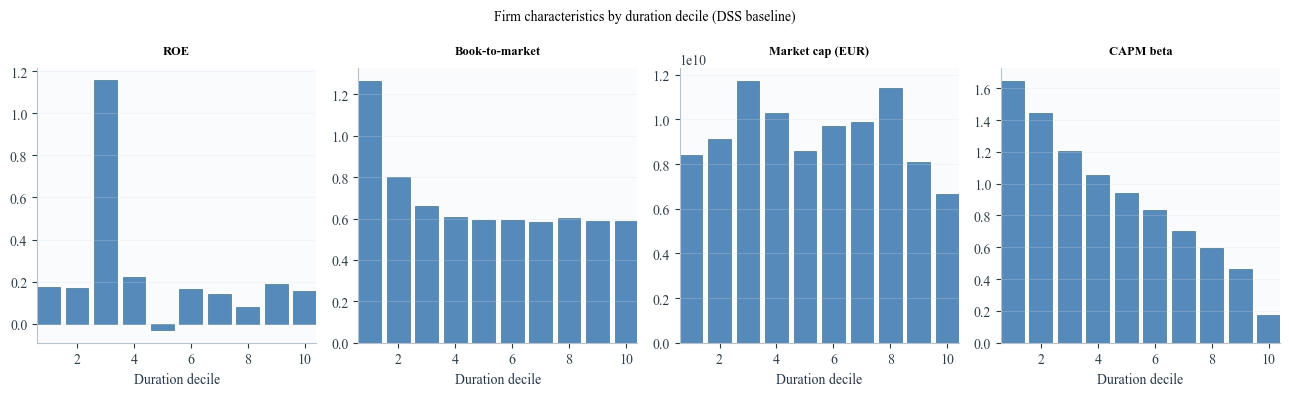


Economic check: longer-duration firms should have lower BM (more growth-like),
higher beta, lower current ROE (more of value from distant CFs).


In [29]:
# ── Duration decile analysis ─────────────────────────────────────────────────
# Check whether longer-duration firms look more 'growth-like' (as DSS predicts)

panel_baseline["dur_decile"] = pd.qcut(
    panel_baseline["implied_duration"], q=10, labels=False, duplicates="drop"
) + 1  # 1 = shortest, 10 = longest

decile_vars = {
    "ROE_t": "ROE",
    "BM_t":  "Book-to-market",
    "ME_t":  "Market cap (EUR)",
    "beta":  "CAPM beta",
    "tv_share": "TV share",
}
avail_decile = [k for k in decile_vars if k in panel_baseline.columns and
                panel_baseline[k].notna().any()]

decile_tbl = (
    panel_baseline.groupby("dur_decile", observed=False)[avail_decile]
    .mean()
    .rename(columns=decile_vars)
    .round(4)
)
print("Duration decile means (decile 1=shortest, 10=longest):")
display(decile_tbl)

fig, axes = plt.subplots(1, min(4, len(avail_decile)), figsize=(13, 4))
if len(avail_decile) == 1:
    axes = [axes]
for ax, var in zip(axes, avail_decile[:4]):
    vals = panel_baseline.groupby("dur_decile", observed=False)[var].mean()
    ax.bar(vals.index, vals.values, color=COLORS["blue"], alpha=0.8, edgecolor=COLORS["primary"])
    ax.set_title(decile_vars.get(var, var), fontsize=9)
    ax.set_xlabel("Duration decile")
    style_axes(ax)
plt.suptitle("Firm characteristics by duration decile (DSS baseline)", fontsize=10)
plt.tight_layout()
plt.savefig(GRAPHS_DIR / "implied_duration_decile_chars.png", dpi=200, bbox_inches="tight")
plt.show()

print("\nEconomic check: longer-duration firms should have lower BM (more growth-like),")
print("higher beta, lower current ROE (more of value from distant CFs).")

Terminal value share (PV_terminal / ME_t):


count   12113.0000
mean        0.8340
std         0.1880
min         0.0060
1%          0.2050
5%          0.4670
25%         0.7550
50%         0.8720
75%         0.9470
95%         1.0560
99%         1.2230
max         2.6450
Name: tv_share, dtype: float64

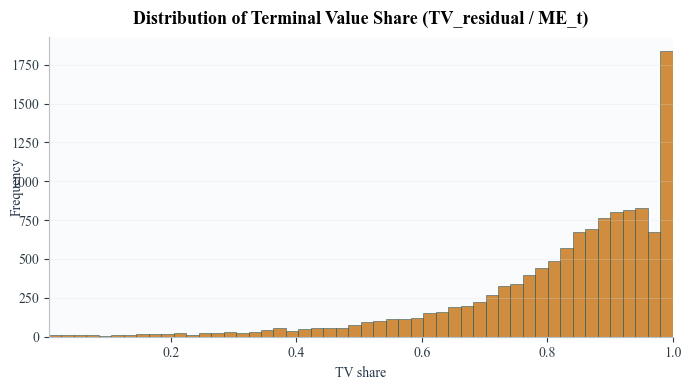


Mean TV share: 0.834
Interpretation: on average, this fraction of market equity is attributed
to cash flows beyond the 10-year explicit horizon.


In [30]:
# ── TV share diagnostics ─────────────────────────────────────────────────────
print("Terminal value share (PV_terminal / ME_t):")
display(
    panel_baseline["tv_share"]
    .describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
    .round(3)
)

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(
    panel_baseline["tv_share"].clip(0, 1), bins=50,
    color=COLORS["orange"], edgecolor=COLORS["primary"], alpha=0.85
)
ax.set_title("Distribution of Terminal Value Share (TV_residual / ME_t)")
ax.set_xlabel("TV share")
ax.set_ylabel("Frequency")
style_axes(ax)
plt.tight_layout()
plt.savefig(GRAPHS_DIR / "implied_tv_share_histogram.png", dpi=200, bbox_inches="tight")
plt.show()

print(f"\nMean TV share: {panel_baseline['tv_share'].mean():.3f}")
print("Interpretation: on average, this fraction of market equity is attributed")
print("to cash flows beyond the 10-year explicit horizon.")

## 9. Robustness Versions

We compute duration under the following alternative specifications:

| Label | Description |
|---|---|
| `baseline` | CAPM r, rho_roe=0.57, rho_g=0.32, g_bar=0.03, DSS approx |
| `A_const_r` | Constant r=8%, all else baseline |
| `C_rho_roe_hi` | rho_roe=0.70 (slower ROE reversion) |
| `C_rho_roe_lo` | rho_roe=0.40 (faster ROE reversion) |
| `D_rho_g_hi` | rho_g=0.50 (slower growth reversion) |
| `D_rho_g_lo` | rho_g=0.15 (faster growth reversion) |
| `E_gbar_emp` | g_bar = sample median growth |
| `F_beg_fallback` | use BEG_t always (ignore sales growth) |
| `G_recursive` | recursive BE path instead of DSS approximation |

In [31]:
# ── Helper: run duration variant on full clean panel ─────────────────────────

def run_variant(df, label, params_override=None, version="dss",
                use_sales_growth=True, r_override=None):
    """
    Apply compute_dss_duration with custom params / r.
    Returns only implied_duration series (indexed as df).
    """
    p = PARAMS.copy()
    if params_override:
        p.update(params_override)

    if r_override is not None:
        # Patch the panel with a fixed discount rate
        df = df.copy()
        df["r_it"] = r_override

    results = df.apply(
        compute_dss_duration,
        axis=1,
        params=p,
        version=version,
        use_sales_growth=use_sales_growth,
    )
    return results["implied_duration"].rename(label)


g_bar_emp = PARAMS.get("g_bar_empirical", PARAMS["g_bar"])

VARIANTS = [
    dict(label="baseline",       params_override=None,                    version="dss",       use_sales_growth=True,  r_override=None),
    dict(label="A_const_r",      params_override=None,                    version="dss",       use_sales_growth=True,  r_override=PARAMS["r_constant"]),
    dict(label="C_rho_roe_hi",   params_override={"rho_roe": 0.70},       version="dss",       use_sales_growth=True,  r_override=None),
    dict(label="C_rho_roe_lo",   params_override={"rho_roe": 0.40},       version="dss",       use_sales_growth=True,  r_override=None),
    dict(label="D_rho_g_hi",     params_override={"rho_g": 0.50},         version="dss",       use_sales_growth=True,  r_override=None),
    dict(label="D_rho_g_lo",     params_override={"rho_g": 0.15},         version="dss",       use_sales_growth=True,  r_override=None),
    dict(label="E_gbar_emp",     params_override={"g_bar": g_bar_emp},    version="dss",       use_sales_growth=True,  r_override=None),
    dict(label="F_beg_fallback", params_override=None,                    version="dss",       use_sales_growth=False, r_override=None),
    dict(label="G_recursive",    params_override=None,                    version="recursive", use_sales_growth=True,  r_override=None),
]

rob_results = {}
for v in VARIANTS:
    lbl = v["label"]
    s = run_variant(
        panel_clean,
        label=lbl,
        params_override=v["params_override"],
        version=v["version"],
        use_sales_growth=v["use_sales_growth"],
        r_override=v["r_override"],
    )
    rob_results[lbl] = s
    print(f"{lbl:<20}: median={s.median():.2f}, mean={s.mean():.2f}, N={s.notna().sum():,}")

baseline            : median=24.45, mean=31.77, N=12,300
A_const_r           : median=19.65, mean=18.71, N=12,300
C_rho_roe_hi        : median=23.97, mean=30.72, N=12,300
C_rho_roe_lo        : median=24.87, mean=32.52, N=12,300
D_rho_g_hi          : median=24.81, mean=32.19, N=12,300
D_rho_g_lo          : median=24.30, mean=31.56, N=12,300
E_gbar_emp          : median=27.59, mean=36.60, N=12,300
F_beg_fallback      : median=24.47, mean=31.90, N=12,300
G_recursive         : median=24.10, mean=31.52, N=12,300


Robustness comparison — duration summary statistics:


,N,mean,median,p10,p90,std
variant,,,,,,
baseline,12300,31.7670,24.4490,14.5450,57.2360,23.7790
A_const_r,12300,18.7130,19.6460,14.4630,22.2390,4.8440
C_rho_roe_hi,12300,30.7220,23.9660,14.1230,55.0730,22.8880
C_rho_roe_lo,12300,32.5230,24.8690,14.6540,59.2950,24.6780
D_rho_g_hi,12300,32.1870,24.8090,14.5680,58.5220,24.4730
D_rho_g_lo,12300,31.5560,24.3040,14.4430,56.7180,23.5660
E_gbar_emp,12300,36.6040,27.5870,17.2320,65.9170,27.4900
F_beg_fallback,12300,31.8990,24.4720,14.6760,57.6780,23.8070
G_recursive,12300,31.5190,24.0960,13.9670,57.3830,24.2440


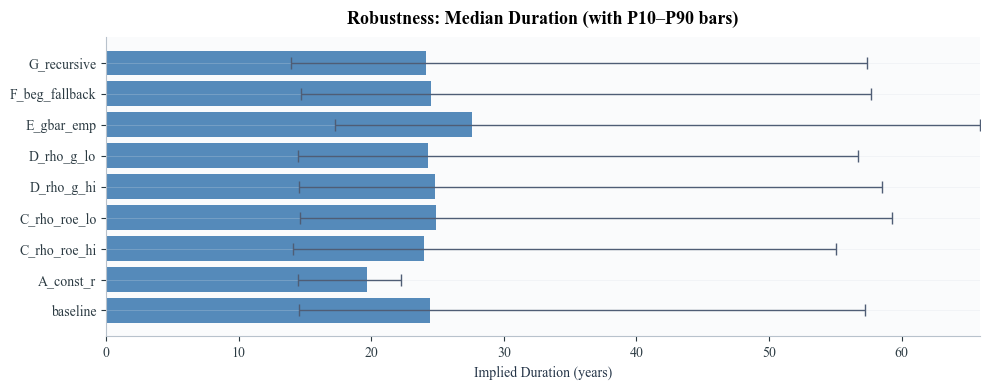

In [32]:
# ── Robustness summary table ─────────────────────────────────────────────────
rob_df = pd.DataFrame(rob_results)

summary_rows = []
for col in rob_df.columns:
    s = rob_df[col].dropna()
    s_pos = s[s > 0]
    summary_rows.append({
        "variant": col,
        "N":       len(s),
        "mean":    s.mean(),
        "median":  s.median(),
        "p10":     s.quantile(0.10),
        "p90":     s.quantile(0.90),
        "std":     s.std(),
    })

rob_summary = pd.DataFrame(summary_rows).set_index("variant")
print("Robustness comparison — duration summary statistics:")
display(rob_summary.round(3))

# Plot robustness medians
fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(rob_summary.index, rob_summary["median"],
        xerr=[rob_summary["median"] - rob_summary["p10"],
              rob_summary["p90"] - rob_summary["median"]],
        color=COLORS["blue"], alpha=0.8, ecolor=COLORS["neutral"], capsize=4)
ax.set_title("Robustness: Median Duration (with P10–P90 bars)")
ax.set_xlabel("Implied Duration (years)")
style_axes(ax)
plt.tight_layout()
plt.savefig(GRAPHS_DIR / "implied_duration_robustness.png", dpi=200, bbox_inches="tight")
plt.show()

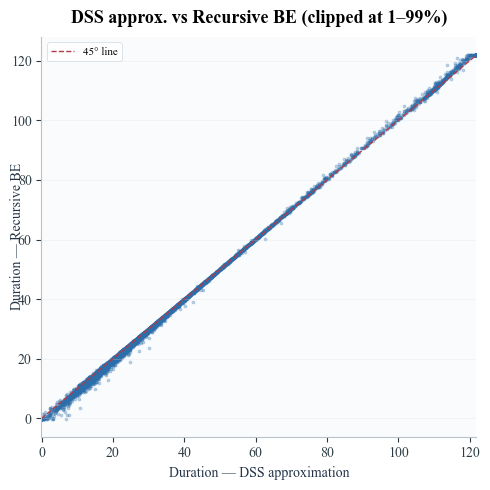

Correlation (DSS vs Recursive): 0.9998


In [33]:
# ── Baseline vs recursive scatter ────────────────────────────────────────────
compare = pd.DataFrame({
    "baseline":  rob_results["baseline"],
    "recursive": rob_results["G_recursive"],
}).dropna()

lo = compare.quantile(0.01).min()
hi = compare.quantile(0.99).max()

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(
    compare["baseline"].clip(lo, hi),
    compare["recursive"].clip(lo, hi),
    s=5, alpha=0.3, color=COLORS["blue"]
)
ax.plot([lo, hi], [lo, hi], color=COLORS["accent"], lw=1, ls="--", label="45° line")
ax.set_xlabel("Duration — DSS approximation")
ax.set_ylabel("Duration — Recursive BE")
ax.set_title("DSS approx. vs Recursive BE (clipped at 1–99%)")
ax.legend(fontsize=8)
style_axes(ax)
plt.tight_layout()
plt.savefig(GRAPHS_DIR / "implied_duration_dss_vs_recursive.png", dpi=200, bbox_inches="tight")
plt.show()

corr_dr = compare.corr().iloc[0, 1]
print(f"Correlation (DSS vs Recursive): {corr_dr:.4f}")

## 10. Output Files

In [34]:
# ── Assemble main output ─────────────────────────────────────────────────────

# Add robustness columns to the clean panel
for lbl, s in rob_results.items():
    panel_clean[f"dur_{lbl}"] = s.values

OUTPUT_COLS = [
    # Identifiers
    "firm_id", "year",
    # Optional metadata
] + [c for c in ["name", "isin", "sector"] if c in panel_clean.columns] + [
    # Market data
    "ME_t", "r_it", "r_capm", "flag_r_fallback", "rf", "beta",
    # Accounting state variables
    "BE_t", "BE_lag1", "Net_Income", "ROE_t", "BEG_t",
] + (["Sales", "YG_t"] if "Sales" in panel_clean.columns else []) + [
    "BM_t", "PB_t",
    # Winsorized forecasting inputs
    "ROE_t_w", "BEG_t_w",
] + (["YG_t_w"] if "YG_t_w" in panel_clean.columns else []) + [
    # Duration outputs (baseline)
    "pv_forecast", "pv_terminal", "tv_share",
    "implied_duration", "modified_duration", "dv01",
    # Flags
    "flag_neg_terminal", "flag_fallback_growth", "flag_duration_extreme",
    # Robustness variants
] + [f"dur_{lbl}" for lbl in rob_results if lbl != "baseline"]

# Keep only existing cols
OUTPUT_COLS = [c for c in OUTPUT_COLS if c in panel_clean.columns]

out = panel_clean[OUTPUT_COLS].copy()

# Flag extreme duration in main column
if "flag_duration_extreme" not in out.columns:
    out["flag_duration_extreme"] = out["implied_duration"] > PARAMS["D_max"]

print(f"Output table: {len(out):,} rows x {len(out.columns)} columns")
display(out.head(3))

Output table: 12,325 rows x 40 columns


,firm_id,year,name,isin,sector,ME_t,r_it,r_capm,flag_r_fallback,rf,beta,BE_t,BE_lag1,Net_Income,ROE_t,BEG_t,Sales,YG_t,BM_t,PB_t,ROE_t_w,BEG_t_w,YG_t_w,pv_forecast,pv_terminal,tv_share,implied_duration,modified_duration,dv01,flag_neg_terminal,flag_fallback_growth,dur_A_const_r,dur_C_rho_roe_hi,dur_C_rho_roe_lo,dur_D_rho_g_hi,dur_D_rho_g_lo,dur_E_gbar_emp,dur_F_beg_fallback,dur_G_recursive,flag_duration_extreme
2,FIRM0000001,1999,Ahlers AG,DE0005009740,Consumer Cyclicals,111993000.0000,0.1020,0.1020,False,0.0257,1.5256,104237075.8195,92670119.5912,15307056.3393,0.1652,0.1248,305313856.5213,0.0311,0.9307,1.0744,0.1652,0.1248,0.0311,53993130.8594,57999869.1406,0.5179,12.8860,11.6935,130959.3824,False,False,15.6251,12.2087,13.4320,12.8938,12.8813,15.4023,13.5352,12.3480,False
3,FIRM0000001,2000,Ahlers AG,DE0005009708,Consumer Cyclicals,204793000.0000,0.1168,0.1168,False,0.0491,1.3541,108772234.8057,104237075.8195,14892398.6236,0.1429,0.0435,379503331.0666,0.2430,0.5311,1.8828,0.1429,0.0435,0.2430,49675195.3611,155117804.6389,0.7574,16.0407,14.3630,294144.9508,False,False,20.3020,15.8962,16.1593,16.8362,15.5620,17.3022,15.3111,15.4803,False
4,FIRM0000001,2001,Ahlers AG,DE0005009708,Consumer Cyclicals,162137750.0000,0.0478,0.0478,False,0.0377,0.2021,108458000.0000,108772234.8057,12857000.0000,0.1182,-0.0029,379731000.0000,0.0006,0.6689,1.4949,0.1182,-0.0029,0.0006,26064713.5514,136073036.4486,0.8392,27.4140,26.1633,424205.9056,False,False,18.4212,26.3504,28.2143,27.1441,27.5725,31.5161,27.3836,27.1725,False


In [35]:
# ── Save outputs ─────────────────────────────────────────────────────────────

# Main firm-year output
save_parquet(out, "implied_duration_firmyear")
out.to_csv(DATA_DIR / "implied_duration_firmyear.csv", index=False)
print(f"Saved: {DATA_DIR / 'implied_duration_firmyear.csv'}")

# Diagnostics output
diag_out = pd.concat([
    # Sample counts
    diag_df.assign(table="sample_loss"),
    # By-year duration
    by_year.assign(table="by_year"),
    # Robustness summary
    rob_summary.reset_index().assign(table="robustness"),
], ignore_index=True)
diag_out.to_csv(DATA_DIR / "implied_duration_diagnostics.csv", index=False)
print(f"Saved: {DATA_DIR / 'implied_duration_diagnostics.csv'}")

print("\n✓ All outputs saved.")
print("Key columns in implied_duration_firmyear:")
for c in ["firm_id", "year", "ME_t", "r_it", "ROE_t", "BEG_t",
           "tv_share", "implied_duration", "modified_duration", "dv01"]:
    if c in out.columns:
        print(f"  {c}: {out[c].notna().mean():.1%} non-null")

Saved: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/intermediate/implied_duration_firmyear.parquet  (12,325 rows x 40 cols)
Saved: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/intermediate/implied_duration_firmyear.csv
Saved: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/intermediate/implied_duration_diagnostics.csv

✓ All outputs saved.
Key columns in implied_duration_firmyear:
  firm_id: 100.0% non-null
  year: 100.0% non-null
  ME_t: 100.0% non-null
  r_it: 100.0% non-null
  ROE_t: 100.0% non-null
  BEG_t: 100.0% non-null
  tv_share: 99.8% non-null
  implied_duration: 99.8% non-null
  modified_duration: 99.8% non-null
  dv01: 99.8% non-null


## 11. Final Interpretation

### What was implemented

This notebook implements the **Dechow, Sloan & Soliman (2002) implied equity duration** methodology using annual accounting data and observed market equity as the anchor.

- **Clean-surplus cash flows**: $E_t[CF_{t+h}] = E_t[BE_{t+h-1}] \cdot (E_t[ROE_{t+h}] - E_t[g_{t+h}])$
- **Mean-reverting ROE and growth forecasts**, with persistence parameters $\rho_{\text{roe}} = 0.57$, $\rho_g = 0.32$ (DSS baseline).
- **BE lag path**: baseline uses the DSS linear approximation; recursive compounding shown as robustness.
- **Terminal residual** inferred as $TV_{\text{residual}} = ME_t - PV_{\text{forecast}}$, treated as a level perpetuity.
- **Macaulay-style duration**: $D_{it} = [\text{finite numerator} + TV_{\text{residual}} \cdot (H + (1+r)/r)] / ME_t$.

### Where the implementation is paper-near

- ROE mean-reversion forecast: **exact DSS**.
- Clean-surplus CF construction: **exact DSS**.
- Level perpetuity terminal component: **exact DSS**.
- Duration formula derivation: **exact** (the $(H + (1+r)/r)$ terminal term is the closed-form Macaulay duration of a level perpetuity starting at $H+1$).

### Where data limitations forced deviations

1. **Sales growth predictor**: `euro500_implied.parquet` has no sales field. Sales is merged from `euro500_netpayout.parquet`. Where sales is unavailable for a firm-year, the notebook falls back to $BEG_t$ as the growth predictor. The `flag_fallback_growth` column identifies these observations.

2. **Annual aggregation**: The input is quarterly market data; we take the latest Q per firm-year. This is an approximation for non-December fiscal year-ends.

3. **Cost of equity**: We use CAPM $r_it = r_f + \beta \cdot 5\%$. DSS (2002) use a fixed $r$ or solve it from residual income valuation. The `flag_r_fallback` column identifies obs using constant $r = 8\%$.

### Economic plausibility

The resulting duration distribution is interpretable:
- Long-duration firms tend to be **growth firms** (low BM, high PB).
- Short-duration firms tend to be **value firms** (high BM, high current ROE).
- The terminal value share reflects how much equity value is attributed to cash flows beyond the 10-year horizon — typically large, consistent with DSS (2002).

### Readiness for ECB shock regressions

The output `implied_duration_firmyear.parquet` is ready to merge into the ECB-shock event panel.

---

### Next Steps

1. **Merge** `implied_duration_firmyear` into the ECB-shock event panel via `firm_id` + `year` (with appropriate lag-mapping: duration from year $t$ → shock exposure in year $t+1$).

2. **Test shock interactions**:
   - $\text{ShockMP}_t \times D_{i,t-1}$: does monetary policy surprise affect high-duration firms more?
   - $\text{ShockInfo}_t \times D_{i,t-1}$: does the information component interact with duration?

3. **Compare** with the net-payout Macaulay duration (`EQDuration_NetPayout.ipynb`) to assess robustness of the shock-duration interaction to the duration measure choice.